# Evaluación metodológica de *targets* supervisados

**Pregunta que responde:** audita la viabilidad metodológica de los métodos de etiquetado supervisado del contrato congelado sobre un símbolo piloto, antes de materializarlos en el pipeline de modelado.

**No cubre:**
- distribuciones globales/*missingness*/correlaciones del *feature set* (eso vive en `02_features/01_eda_features_intermedias.ipynb`),
- la materialización canónica del *modeling dataset* y su cierre de aceptación (eso vive en `03_dataset_supervisado/01_evidencia_dataset_modelado.ipynb`),
- preexperimento FFD o screening de columnas (eso vive en `04_preexperimento/`),
- decisiones de *subset* final de *features* (metodología en `02_features/03_metodologia_seleccion_features.ipynb`, *subset* retenido en *bundles* experimentales).

**Productos:** figura de distribución por *split* (`class_distribution_by_method_split_btcusdt.png`) bajo `reports/figures/features/`; figuras de descriptores TS y matrices de confusión (`trend_scanning_descriptors_btcusdt.png`, `cross_method_confusion_btcusdt.png`) bajo `reports/eda/target_labeling_methodology/`.

## Métodos comparados

Los tres métodos del contrato congelado de etiquetado:

1. `fixed_horizon` -> retorno realizado a horizonte fijo `H`, banda neutra absoluta sobre el retorno.
2. `triple_barrier` -> tres barreras (TP, SL, vertical) escaladas por volatilidad EWMA, primer toque define la clase. En la figura de distribución por *split* se contrastan la variante *baseline* (muestreo `all_bars`, vertical neutra) y la **alineada a experimentos Exp1** (`cusum`, vertical por signo del retorno), según `target_overrides.triple_barrier` en la lista corta *baseline*.
3. `trend_scanning` -> escaneo de ventanas futuras y elección por mayor `|t-value|`.

Para cada método se reportan, sobre un símbolo piloto y un *split* temporal *train* / *test* puramente cronológico:

- distribución de clases (`label_side` ∈ {-1, 0, +1}),
- duración efectiva del evento (`horizon_bars_effective`),
- en `triple_barrier`, tasa de toque por barrera (`tp` / `sl` / `vertical`),
- solapamiento medio entre eventos (`avg_uniqueness`) y concurrencia máxima,
- coste de neutralización y desacuerdo direccional entre `event_outcome` (signo crudo del retorno) y `label_side`,
- **integridad temporal** (clave única `(symbol, event_start_ts)`, ausencia de nulos en columnas obligatorias, duraciones no negativas, `horizon_bars_effective` dentro de `[1, max_horizon_bars]`),
- **causalidad operativa** (`decision_ts <= execution_ts <= event_start_ts <= event_end_ts`, y en `triple_barrier` `event_start_ts <= hit_ts <= event_end_ts`),
- en `triple_barrier`, **verificación física de toques TP/SL contra el OHLCV** (`high` / `low`) entre `event_start_ts` y `hit_ts`,
- en `trend_scanning`, **diagnóstico específico** de `best_horizon_bars`, `|best_t_value|` y coherencia `best_slope_sign -> label_side`,
- **solape cross-method** entre variantes de `triple_barrier` (`baseline` y Exp1) y `{trend_scanning, fixed_horizon}` mediante matrices de confusión 3×3 sobre el índice común de eventos.

## Alcance y cierre

Este notebook **audita** la viabilidad metodológica de cada familia de etiquetado sobre un símbolo piloto: distribución, solapamiento, integridad, causalidad, coherencia física (TB) y solape entre métodos. **No** persiste parquets ni cierra qué método gana en el estudio confirmatorio (eso vive aguas abajo en `05_modelado_predictivo/`).

En producción, `fixed_horizon` y `trend_scanning` persisten en `data/03_processed/targets/<SYMBOL>/<METHOD>/`; la variante `triple_barrier` alineada a la lista corta baseline (CUSUM + vertical por signo) materializa en `data/03_processed/exp1_triple_barrier_cusum_return_sign/targets/<SYMBOL>/triple_barrier/`, según `config/baseline_shortlist.yaml`. Los parquets del *modeling dataset* se construyen desde `03_dataset_supervisado/01_evidencia_dataset_modelado.ipynb` y el *workflow* oficial.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise FileNotFoundError("No se encontró la raíz del repositorio (carpeta src/).")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import logging
import os

import structlog

structlog.reset_defaults()
structlog.configure(
    processors=[structlog.processors.JSONRenderer()],
    logger_factory=structlog.PrintLoggerFactory(
        file=open(os.devnull, "w", encoding="utf-8")
    ),
    wrapper_class=structlog.make_filtering_bound_logger(logging.CRITICAL),
    cache_logger_on_first_use=True,
)
_root = logging.getLogger()
_root.setLevel(logging.CRITICAL)
for _handler in list(_root.handlers):
    _handler.setLevel(logging.CRITICAL)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.targets.contract import (
    NEUTRAL_LABEL_SIDE,
    EventSamplingMode,
    NeutralBandMode,
    PriceTriggerMode,
    SideMode,
    TargetMethod,
    VerticalBarrierLabelMode,
    VolatilityEstimator,
    describe_method_operational_contract,
    frozen_target_labeling_contract_metadata,
)
from src.targets.labeling import build_event_labels_from_features
from src.targets.supervised_dataset_workflow import build_target_config_from_method

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format

INTERMEDIATE_DIR = ROOT / "data" / "02_intermediate"
REPORT_DIR = ROOT / "reports" / "eda" / "target_labeling_methodology"
REPORT_DIR.mkdir(parents=True, exist_ok=True)



## 1. Contrato congelado de etiquetado

Antes de cualquier evaluación, se vuelca el contrato operativo congelado para que la narrativa metodológica quede anclada al código. Cualquier cambio en estos campos exige actualizar `CONTRACT_VERSION` en el módulo de contrato.


In [2]:
contract_meta = frozen_target_labeling_contract_metadata()

summary = {
    "contract_id": contract_meta["contract_id"],
    "contract_version": contract_meta["contract_version"],
    "bar_interval_hours": contract_meta["bar_interval_hours"],
    "label_side_domain": contract_meta["label_side_domain"],
    "neutral_label_side": contract_meta["neutral_label_side"],
}
CONTRACT_SUMMARY_COLUMNS_ES = {
    "contract_id": "id_contrato",
    "contract_version": "version_contrato",
    "bar_interval_hours": "intervalo_barras_h",
    "label_side_domain": "dominio_label_side",
    "neutral_label_side": "label_side_neutro",
}
display(
    pd.Series(summary, name="valor")
    .rename(index=CONTRACT_SUMMARY_COLUMNS_ES)
    .to_frame()
)

method_rows = []
for method in TargetMethod:
    op = describe_method_operational_contract(method)
    method_rows.append(
        {
            "method": op["method"],
            "event_definition": op["event_definition"],
            "label_rule": op["label_rule"],
            "max_event_span_bars": op["max_event_span_bars"],
            "min_purge_bars": op["walk_forward_minimum_purge_bars"],
            "min_embargo_bars": op["walk_forward_minimum_embargo_bars"],
        }
    )

CONTRACT_METHOD_COLUMNS_ES = {
    "method": "metodo",
    "event_definition": "definicion_evento",
    "label_rule": "regla_etiquetado",
    "max_event_span_bars": "extension_maxima_barras",
    "min_purge_bars": "purga_minima_barras",
    "min_embargo_bars": "embargo_minimo_barras",
}
display(pd.DataFrame(method_rows).rename(columns=CONTRACT_METHOD_COLUMNS_ES))

,valor
id_contrato,supervised-target-labeling-v1
version_contrato,2026-03-26-v1
intervalo_barras_h,4
dominio_label_side,"[-1, 0, 1]"
label_side_neutro,0


,metodo,definicion_evento,regla_etiquetado,extension_maxima_barras,purga_minima_barras,embargo_minimo_barras
0,fixed_horizon,retorno ejecutable open(t+1) -> close(t+h),"label_side en {-1,0,1} con banda neutra determ...",6,6,6
1,triple_barrier,evento desde ejecución con first touch sobre T...,label_side por primera barrera tocada; neutra ...,6,6,6
2,trend_scanning,escaneo de ventanas futuras y selección por ma...,label_side = signo de la pendiente solo si sup...,24,24,24


## 2. Carga del símbolo piloto y *split* temporal

Se elige `BTCUSDT` como símbolo piloto por ser la serie con mayor cobertura. El *split* *train*/*test* es **estrictamente cronológico** y se usa solo para que las métricas de calibración (estabilidad, balance) puedan compararse fuera de muestra; **no** se entrena ningún modelo aquí.

El parquet intermedio cubre hasta el freeze académico operativo del proyecto (`fin_utc` en la tabla siguiente). El número de *event labels* generados puede ser ligeramente inferior al de filas de features: barras iniciales sin historial suficiente (volatilidad, ventanas de escaneo) o cola final sin horizonte completo.


In [3]:
PILOT_SYMBOL = "BTCUSDT"
TRAIN_TEST_SPLIT_RATIO = 0.80

features_path = INTERMEDIATE_DIR / f"{PILOT_SYMBOL.lower()}_features_4h.parquet"
if not features_path.exists():
    raise FileNotFoundError(
        f"No existe el parquet de features para {PILOT_SYMBOL}: {features_path}.\n"
        "Materializa primero la capa intermedia con `python -m src.main features`."
    )

features_df = pd.read_parquet(features_path)
if not isinstance(features_df.index, pd.DatetimeIndex):
    if "timestamp" in features_df.columns:
        features_df = features_df.set_index("timestamp")
    features_df.index = pd.DatetimeIndex(features_df.index)
features_df = features_df.sort_index()

split_pos = int(len(features_df) * TRAIN_TEST_SPLIT_RATIO)
split_ts = features_df.index[split_pos]

display(
    pd.Series(
        {
            "simbolo": PILOT_SYMBOL,
            "filas": len(features_df),
            "inicio_utc": features_df.index.min(),
            "fin_utc": features_df.index.max(),
            "split_ratio": TRAIN_TEST_SPLIT_RATIO,
            "split_ts": split_ts,
            "filas_train": split_pos,
            "filas_test": len(features_df) - split_pos,
        },
        name="valor",
    ).to_frame()
)

,valor
simbolo,BTCUSDT
filas,18707
inicio_utc,2017-08-17 04:00:00
fin_utc,2026-02-28 20:00:00
split_ratio,0.8000
split_ts,2024-06-15 08:00:00
filas_train,14965
filas_test,3742


## 3. Construcción de *event labels* por método

Para cada método se construye una `TargetConfig` reproducible y se generan `event_labels` en memoria (no se persisten parquets desde este notebook). `fixed_horizon` y `trend_scanning` siguen los *defaults* del *workflow*; para `triple_barrier` se evalúan **dos** configuraciones: la *baseline* histórica del notebook (`all_bars` + vertical neutra) y la **alineada a la lista corta baseline** (`config/baseline_shortlist.yaml`: CUSUM + `return_sign` en vertical).

Parámetros numéricos compartidos entre ambas triple barrera:

- vertical `6` barras, volatilidad EWMA lookback `42`, `pt_mult = sl_mult = 2.0`, `min_ret = 0`, evaluación `high_low`, `long_short`.

Variantes:

- `triple_barrier_baseline`: `event_sampling_mode = all_bars`, `vertical_label_mode = neutral` (vertical -> `label_side = 0`).
- `triple_barrier_exp1`: parámetros de `target_overrides.triple_barrier` en la lista corta baseline (`cusum` con umbral dinámico, `vertical_label_mode = return_sign`).

- `fixed_horizon`: `H = 6` barras 4h (24h), banda neutra absoluta `0.005`.
- `trend_scanning`: ventanas `[3, 24]` con paso `1`, umbral `|t| >= 2.0`, regresión OLS sobre `close`.


In [4]:
method_configs = {
    "fixed_horizon": build_target_config_from_method(
        TargetMethod.FIXED_HORIZON,
        horizon_bars=6,
        neutral_band_mode=NeutralBandMode.ABS_RETURN,
        neutral_band_value=0.005,
    ),
    "triple_barrier_baseline": build_target_config_from_method(
        TargetMethod.TRIPLE_BARRIER,
        vertical_horizon_bars=6,
        volatility_lookback_bars=42,
        volatility_estimator=VolatilityEstimator.EWMA,
        pt_mult=2.0,
        sl_mult=2.0,
        min_ret=0.0,
        price_trigger_mode=PriceTriggerMode.HIGH_LOW,
        side_mode=SideMode.LONG_SHORT,
        event_sampling_mode=EventSamplingMode.ALL_BARS,
        vertical_label_mode=VerticalBarrierLabelMode.NEUTRAL,
    ),
    "triple_barrier_exp1": build_target_config_from_method(
        TargetMethod.TRIPLE_BARRIER,
        vertical_horizon_bars=6,
        volatility_lookback_bars=42,
        volatility_estimator=VolatilityEstimator.EWMA,
        pt_mult=2.0,
        sl_mult=2.0,
        min_ret=0.0,
        price_trigger_mode=PriceTriggerMode.HIGH_LOW,
        side_mode=SideMode.LONG_SHORT,
        event_sampling_mode=EventSamplingMode.CUSUM,
        cusum_threshold=0.0,
        cusum_volatility_mult=1.0,
        vertical_label_mode=VerticalBarrierLabelMode.RETURN_SIGN,
    ),
    "trend_scanning": build_target_config_from_method(
        TargetMethod.TREND_SCANNING,
        min_scan_bars=3,
        max_scan_bars=24,
        scan_step_bars=1,
        tvalue_threshold=2.0,
    ),
}

event_labels_by_method: dict[str, pd.DataFrame] = {}
for label_key, cfg in method_configs.items():
    result = build_event_labels_from_features(
        features_df,
        symbol=PILOT_SYMBOL,
        target_config=cfg,
    )
    event_labels_by_method[label_key] = result.event_labels.copy()

display(
    pd.DataFrame(
        [
            {"metodo": name, "eventos": len(df), "columnas": len(df.columns)}
            for name, df in event_labels_by_method.items()
        ]
    ).set_index("metodo")
)

,eventos,columnas
metodo,,
fixed_horizon,18701,17
triple_barrier_baseline,18701,24
triple_barrier_exp1,6063,24
trend_scanning,18683,21


## 4. Distribución de clases por método

Diagnóstico clave para detectar *imbalance* severo o colapso a clase neutra. Se reporta la distribución **cruda** (sin rebalanceo). Cualquier *resampling* pertenece al *loop* de entrenamiento por *fold*, no a este notebook.

La figura guardada bajo `reports/figures/features/` incluye **dos** paneles para triple barrera: la variante *baseline* del notebook (`all_bars` + vertical neutra) y la variante **alineada a Exp1** (`cusum` + vertical por signo del retorno).


In [5]:
def class_distribution_split(
    event_labels: pd.DataFrame,
    *,
    split_ts: pd.Timestamp,
) -> pd.DataFrame:
    decision = pd.to_datetime(event_labels["decision_ts"])
    parts = []
    for split_name, mask in (
        ("train", decision < split_ts),
        ("test", decision >= split_ts),
        ("all", pd.Series(True, index=event_labels.index)),
    ):
        slice_df = event_labels.loc[mask, "label_side"]
        if slice_df.empty:
            continue
        counts = slice_df.value_counts().sort_index()
        proportions = counts / counts.sum()
        for side, count in counts.items():
            parts.append(
                {
                    "split": split_name,
                    "label_side": int(side),
                    "count": int(count),
                    "proportion": float(proportions[side]),
                }
            )
    return pd.DataFrame(parts)


CLASS_DIST_METHOD_LABELS = {
    "fixed_horizon": "fixed_horizon",
    "triple_barrier_baseline": "triple_barrier (baseline: all_bars, neutral_vertical)",
    "triple_barrier_exp1": "triple_barrier (Exp1: cusum, return_sign_vertical)",
    "trend_scanning": "trend_scanning",
}

CLASS_DIST_COLUMNS_ES = {
    "split": "particion",
    "label_side": "label_side",
    "count": "conteo",
    "proportion": "proporcion",
}

BARRIER_SPLIT_COLUMNS_ES = {
    "split": "particion",
    "hit_barrier": "barrera",
    "proportion": "proporcion",
    "events": "eventos",
}

COHERENCE_COLUMNS_ES = {
    "events": "eventos",
    "neutralized_nonzero_outcome_share": "proporcion_outcome_neutralizado",
    "directional_sign_disagreement_share": "proporcion_desacuerdo_direccional",
}

class_tables = {}
class_dist_frames = []
for method_name, labels_df in event_labels_by_method.items():
    table = class_distribution_split(labels_df, split_ts=split_ts)
    class_tables[method_name] = table
    labeled = table.rename(columns=CLASS_DIST_COLUMNS_ES).copy()
    labeled.insert(
        0,
        "metodo",
        CLASS_DIST_METHOD_LABELS.get(method_name, method_name),
    )
    class_dist_frames.append(labeled)

display(pd.concat(class_dist_frames, ignore_index=True))

,metodo,particion,label_side,conteo,proporcion
0,fixed_horizon,train,-1,5632,0.3763
1,fixed_horizon,train,0,3055,0.2041
2,fixed_horizon,train,1,6278,0.4195
3,fixed_horizon,test,-1,1397,0.3739
4,fixed_horizon,test,0,884,0.2366
5,fixed_horizon,test,1,1455,0.3895
6,fixed_horizon,all,-1,7029,0.3759
7,fixed_horizon,all,0,3939,0.2106
8,fixed_horizon,all,1,7733,0.4135
9,"triple_barrier (baseline: all_bars, neutral_ve...",train,-1,4992,0.3336


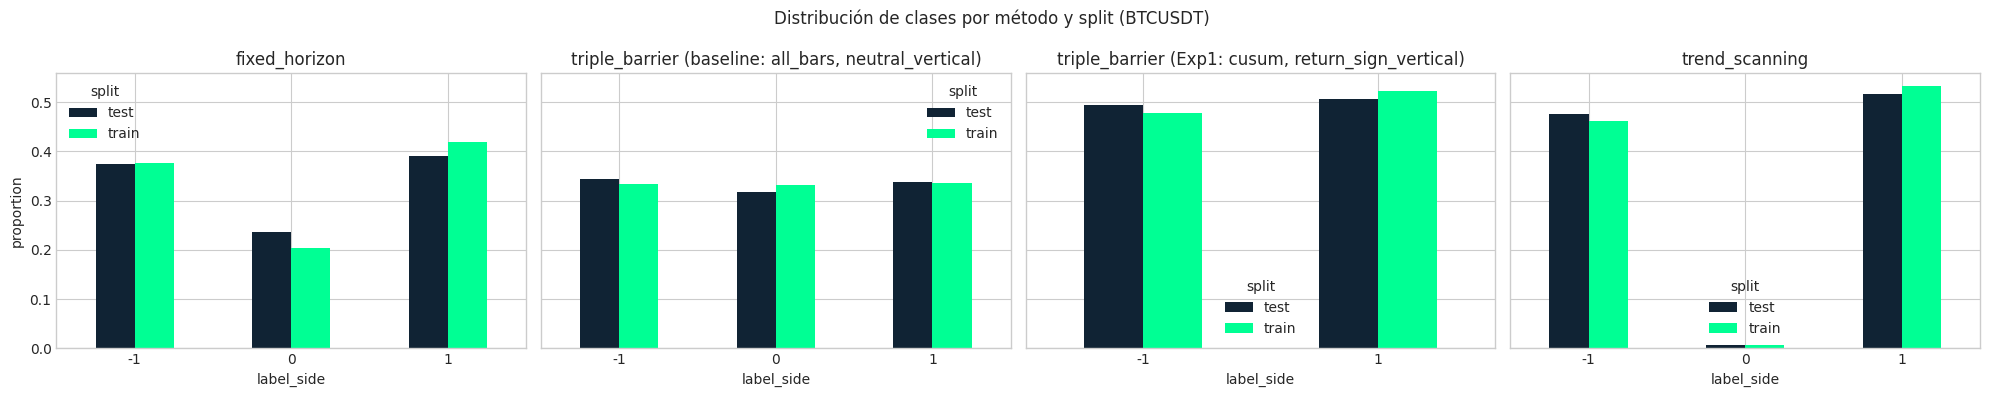

In [6]:
COLOR_TRAIN = "#00ff94"
COLOR_TEST = "#102334"
split_bar_colors = {"train": COLOR_TRAIN, "test": COLOR_TEST}

fig, axes = plt.subplots(1, len(class_tables), figsize=(5 * len(class_tables), 4), sharey=True)
if len(class_tables) == 1:
    axes = [axes]
for ax, (method_name, table) in zip(axes, class_tables.items()):
    pivot = table[table["split"].isin(["train", "test"])].pivot(
        index="label_side", columns="split", values="proportion"
    ).fillna(0.0)
    bar_colors = [split_bar_colors.get(str(col).lower(), "#888888") for col in pivot.columns]
    pivot.plot(kind="bar", ax=ax, rot=0, color=bar_colors)
    ax.set_title(CLASS_DIST_METHOD_LABELS.get(method_name, method_name))
    ax.set_xlabel("label_side")
    ax.set_ylabel("proportion")
    ax.legend(title="split")
    ax.tick_params(axis="x", labelrotation=0)
plt.suptitle(
    f"Distribución de clases por método y split ({PILOT_SYMBOL}) "
)
plt.tight_layout()
fig_dir = ROOT / "reports" / "figures" / "features"
fig_dir.mkdir(parents=True, exist_ok=True)
fig_path = fig_dir / f"class_distribution_by_method_split_{PILOT_SYMBOL.lower()}.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

## 5. Duración efectiva del evento y solapamiento

El solapamiento entre eventos determina las barras mínimas de purga y embargo del *walk-forward*. `avg_uniqueness` aproxima ese efecto a nivel evento; `concurrency` cuenta cuántos eventos abiertos coexisten en cada barra.


In [7]:
OVERLAP_COLUMNS_ES = {
    "events": "eventos",
    "horizon_eff_mean": "horizonte_ef_medio",
    "horizon_eff_p50": "horizonte_ef_p50",
    "horizon_eff_p95": "horizonte_ef_p95",
    "avg_uniqueness_mean": "unicidad_media",
    "concurrency_p50": "concurrencia_p50",
    "concurrency_p95": "concurrencia_p95",
    "concurrency_max": "concurrencia_max",
}

overlap_rows = []
for method_name, labels_df in event_labels_by_method.items():
    horizon_eff = labels_df["horizon_bars_effective"].astype(float)
    overlap_rows.append(
        {
            "method": method_name,
            "events": int(len(labels_df)),
            "horizon_eff_mean": horizon_eff.mean(),
            "horizon_eff_p50": horizon_eff.median(),
            "horizon_eff_p95": horizon_eff.quantile(0.95),
            "avg_uniqueness_mean": labels_df["avg_uniqueness"].astype(float).mean(),
            "concurrency_p50": labels_df["concurrency"].astype(float).median(),
            "concurrency_p95": labels_df["concurrency"].astype(float).quantile(0.95),
            "concurrency_max": labels_df["concurrency"].astype(float).max(),
        }
    )

overlap_df = pd.DataFrame(overlap_rows).set_index("method")
overlap_df = overlap_df.rename(columns=OVERLAP_COLUMNS_ES).rename_axis("metodo")
overlap_df.index = overlap_df.index.map(lambda k: CLASS_DIST_METHOD_LABELS.get(k, k))
display(overlap_df)

,eventos,horizonte_ef_medio,horizonte_ef_p50,horizonte_ef_p95,unicidad_media,concurrencia_p50,concurrencia_p95,concurrencia_max
metodo,,,,,,,,
fixed_horizon,18701,6.0000,6.0000,6.0000,0.1429,7.0000,7.0000,7.0000
"triple_barrier (baseline: all_bars, neutral_vertical)",18701,4.0380,4.0000,6.0000,0.2086,7.0000,7.0000,7.0000
"triple_barrier (Exp1: cusum, return_sign_vertical)",6063,3.8385,4.0000,6.0000,0.5814,3.0000,4.0000,5.0000
trend_scanning,18683,14.7361,15.0000,24.0000,0.0657,22.0000,25.0000,25.0000


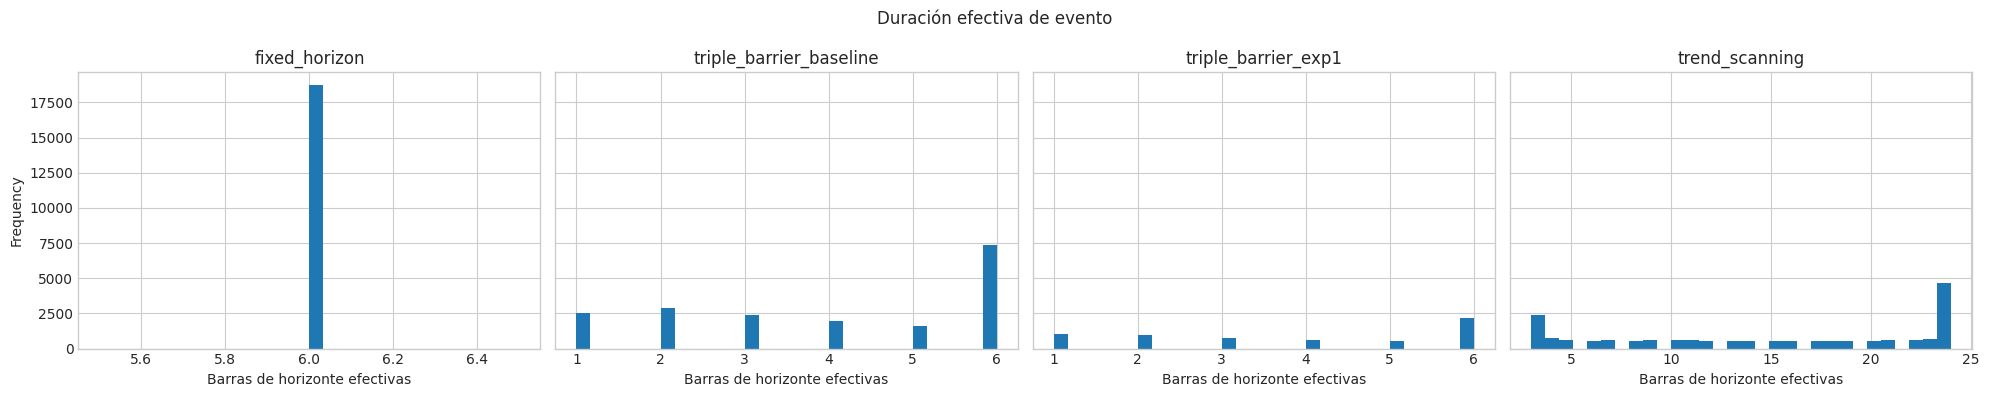

In [8]:
fig, axes = plt.subplots(1, len(event_labels_by_method), figsize=(5 * len(event_labels_by_method), 4), sharey=True)
if len(event_labels_by_method) == 1:
    axes = [axes]
for ax, (method_name, labels_df) in zip(axes, event_labels_by_method.items()):
    horizon_eff = labels_df["horizon_bars_effective"].astype(float)
    horizon_eff.plot(kind="hist", bins=30, ax=ax)
    ax.set_title(f"{method_name}")
    ax.set_xlabel("Barras de horizonte efectivas")
plt.suptitle("Duración efectiva de evento")
plt.tight_layout()
plt.show()

## 6. Integridad temporal y causalidad

Antes de cualquier diagnóstico específico por método se exige que los `event_labels` cumplan el contrato estructural mínimo. Dos bloques:

**Integridad temporal**

- la pareja `(symbol, event_start_ts)` es clave única (no debe haber duplicados);
- `label_side`, `event_outcome`, `event_start_ts` y `event_end_ts` no admiten nulos;
- `event_end_ts >= event_start_ts` (duraciones no negativas);
- `horizon_bars_effective` está en `[1, max_horizon_bars]`.

**Causalidad operativa**

El orden temporal del evento debe ser `decision_ts <= execution_ts <= event_start_ts <= event_end_ts`. En `triple_barrier`, además, `event_start_ts <= hit_ts <= event_end_ts`. Cualquier violación implica una potencial fuga look-ahead e **invalidaría** la materialización del método afectado.

In [9]:
REQUIRED_NULL_COLS = ["label_side", "event_outcome", "event_start_ts", "event_end_ts"]


def _integrity_row(method_name: str, df: pd.DataFrame) -> dict:
    pk_dups = int(df.duplicated(subset=["symbol", "event_start_ts"]).sum())
    nulls = {f"nulls_{c}": int(df[c].isna().sum()) for c in REQUIRED_NULL_COLS}
    neg_dur = int((df["event_end_ts"] < df["event_start_ts"]).sum())
    horizon_oob = int(
        ((df["horizon_bars_effective"] < 1) | (df["horizon_bars_effective"] > df["max_horizon_bars"])).sum()
    )
    return {
        "method": method_name,
        "events": int(len(df)),
        "pk_duplicates": pk_dups,
        **nulls,
        "negative_duration_rows": neg_dur,
        "horizon_oob_rows": horizon_oob,
    }


def _causality_row(method_name: str, df: pd.DataFrame) -> dict:
    out = {
        "method": method_name,
        "decision_after_execution": int((df["decision_ts"] > df["execution_ts"]).sum()),
        "execution_after_event_start": int((df["execution_ts"] > df["event_start_ts"]).sum()),
        "start_after_end": int((df["event_start_ts"] > df["event_end_ts"]).sum()),
    }
    if method_name.startswith("triple_barrier") and "hit_ts" in df.columns:
        sub = df[df["hit_ts"].notna()]
        out["tb_hit_before_start"] = int((sub["hit_ts"] < sub["event_start_ts"]).sum())
        out["tb_hit_after_end"] = int((sub["hit_ts"] > sub["event_end_ts"]).sum())
    return out


integrity_df = pd.DataFrame(
    [_integrity_row(name, df) for name, df in event_labels_by_method.items()]
).set_index("method")

causality_df = pd.DataFrame(
    [_causality_row(name, df) for name, df in event_labels_by_method.items()]
).set_index("method")

INTEGRITY_COLUMNS_ES = {
    "events": "eventos",
    "pk_duplicates": "duplicados_pk",
    "nulls_label_side": "nulos_label_side",
    "nulls_event_outcome": "nulos_event_outcome",
    "nulls_event_start_ts": "nulos_event_start_ts",
    "nulls_event_end_ts": "nulos_event_end_ts",
    "negative_duration_rows": "filas_duracion_negativa",
    "horizon_oob_rows": "filas_horizonte_fuera_rango",
}

CAUSALITY_CORE_COLUMNS_ES = {
    "decision_after_execution": "decision_despues_ejecucion",
    "execution_after_event_start": "ejecucion_despues_inicio_evento",
    "start_after_end": "inicio_despues_fin",
}

CAUSALITY_TB_COLUMNS_ES = {
    "tb_hit_before_start": "tb_toque_antes_inicio",
    "tb_hit_after_end": "tb_toque_despues_fin",
}

integrity_display = integrity_df.rename(columns=INTEGRITY_COLUMNS_ES).rename_axis("metodo")
integrity_display.index = integrity_display.index.map(lambda k: CLASS_DIST_METHOD_LABELS.get(k, k))
print("Integridad temporal:")
display(integrity_display)

causality_core = causality_df[
    ["decision_after_execution", "execution_after_event_start", "start_after_end"]
].fillna(0).astype(int)
causality_core_display = causality_core.rename(columns=CAUSALITY_CORE_COLUMNS_ES).rename_axis("metodo")
causality_core_display.index = causality_core_display.index.map(lambda k: CLASS_DIST_METHOD_LABELS.get(k, k))
print("\nCausalidad operativa (todos los métodos):")
display(causality_core_display)

tb_methods = [m for m in causality_df.index if m.startswith("triple_barrier")]
if tb_methods:
    causality_tb = causality_df.loc[tb_methods, ["tb_hit_before_start", "tb_hit_after_end"]].fillna(0).astype(int)
    causality_tb_display = causality_tb.rename(columns=CAUSALITY_TB_COLUMNS_ES).rename_axis("metodo")
    causality_tb_display.index = causality_tb_display.index.map(lambda k: CLASS_DIST_METHOD_LABELS.get(k, k))
    print("\nCausalidad operativa (solo triple barrera: coherencia de hit_ts):")
    display(causality_tb_display)

Integridad temporal:


,eventos,duplicados_pk,nulos_label_side,nulos_event_outcome,nulos_event_start_ts,nulos_event_end_ts,filas_duracion_negativa,filas_horizonte_fuera_rango
metodo,,,,,,,,
fixed_horizon,18701,0,0,0,0,0,0,0
"triple_barrier (baseline: all_bars, neutral_vertical)",18701,0,0,0,0,0,0,0
"triple_barrier (Exp1: cusum, return_sign_vertical)",6063,0,0,0,0,0,0,0
trend_scanning,18683,0,0,0,0,0,0,0



Causalidad operativa (todos los métodos):


,decision_despues_ejecucion,ejecucion_despues_inicio_evento,inicio_despues_fin
metodo,,,
fixed_horizon,0,0,0
"triple_barrier (baseline: all_bars, neutral_vertical)",0,0,0
"triple_barrier (Exp1: cusum, return_sign_vertical)",0,0,0
trend_scanning,0,0,0



Causalidad operativa (solo triple barrera: coherencia de hit_ts):


,tb_toque_antes_inicio,tb_toque_despues_fin
metodo,,
"triple_barrier (baseline: all_bars, neutral_vertical)",0,0
"triple_barrier (Exp1: cusum, return_sign_vertical)",0,0


## 7. Diagnósticos específicos de triple barrera (variante experimentos)

Para la variante `triple_barrier_exp1` (CUSUM + `return_sign` en vertical), el diagnóstico clave es la fracción de eventos que cierra por cada barrera (`tp` / `sl` / `vertical`). Una concentración excesiva en `vertical` indicaría que la barrera temporal domina frente a TP/SL y que los multiplicadores de volatilidad están demasiado anchos.

La tabla siguiente (partición `all`) resume el reparto observado en el piloto; la celda de código añade una lectura automática a partir de esos valores.

Adicionalmente, en 7.1, para ambas variantes de triple barrera (`baseline` y `exp1`) verificamos contra el OHLCV (`high` / `low`) que cada cierre por TP / SL ocurrió efectivamente en alguna barra entre `event_start_ts` y `hit_ts`.


In [10]:
tb_df = event_labels_by_method.get("triple_barrier_exp1")
if tb_df is None or tb_df.empty:
    pass
else:
    decision_ts = pd.to_datetime(tb_df["decision_ts"])
    rows = []
    for split_name, mask in (
        ("train", decision_ts < split_ts),
        ("test", decision_ts >= split_ts),
        ("all", pd.Series(True, index=tb_df.index)),
    ):
        sub = tb_df.loc[mask, "hit_barrier"].dropna()
        if sub.empty:
            continue
        counts = sub.value_counts(normalize=True).rename("proportion")
        for barrier, prop in counts.items():
            rows.append(
                {
                    "split": split_name,
                    "hit_barrier": str(barrier),
                    "proportion": float(prop),
                    "events": int((sub == barrier).sum()),
                }
            )
    barrier_df = pd.DataFrame(rows).rename(columns=BARRIER_SPLIT_COLUMNS_ES)
    display(barrier_df)

    all_split = barrier_df[barrier_df["particion"] == "all"].set_index("barrera")["proporcion"]
    tp_share = float(all_split.get("tp", 0.0))
    sl_share = float(all_split.get("sl", 0.0))
    vertical_share = float(all_split.get("vertical", 0.0))
    dominant = max(all_split.items(), key=lambda kv: kv[1])[0]
    if dominant == "vertical" and vertical_share >= 0.50:
        reading = "vertical domina (>= 50%); revisar pt_mult/sl_mult o horizonte"
    elif tp_share + sl_share >= vertical_share:
        reading = "tp y sl superan a vertical; multiplicadores coherentes con el piloto"
    else:
        reading = "reparto atípico; revisar parámetros antes de materializar"
    display(
        pd.Series(
            {
                "tp_pct": round(tp_share, 4),
                "sl_pct": round(sl_share, 4),
                "vertical_pct": round(vertical_share, 4),
                "lectura": reading,
            },
            name="triple_barrier_exp1 (all)",
        ).to_frame()
    )

,particion,barrera,proporcion,eventos
0,train,tp,0.3638,1738
1,train,sl,0.3449,1648
2,train,vertical,0.2913,1392
3,test,sl,0.3751,482
4,test,tp,0.3595,462
5,test,vertical,0.2654,341
6,all,tp,0.3629,2200
7,all,sl,0.3513,2130
8,all,vertical,0.2858,1733


,triple_barrier_exp1 (all)
tp_pct,0.3629
sl_pct,0.3513
vertical_pct,0.2858
lectura,tp y sl superan a vertical; multiplicadores co...


### 7.1. Verificación de toques TP/SL contra el OHLCV

Sobre una muestra aleatoria por barrera (semilla fija), comprobamos que para cada evento con `hit_barrier == "tp"` existe alguna barra en el rango `[event_start_ts, hit_ts]` con `high >= pt_price`, y simétricamente para `hit_barrier == "sl"` con `low <= sl_price`. La tolerancia numérica (`1e-6`) absorbe el redondeo en la materialización de barreras.

Una `confirm_rate` cercana a `1.0` certifica que el *labeler* y el OHLCV son **físicamente coherentes**. Tasas por debajo de `0.99` pueden deberse a redondeo o muestreo; por debajo de `0.95` indican un *bug* potencial en el labeler o en la alineación con el OHLCV.

In [11]:
TB_TOUCH_SAMPLE = 500
TB_TOUCH_TOL = 1e-6

if {"high", "low"}.issubset(features_df.columns):
    ohlcv_hl = features_df[["high", "low"]].sort_index()
else:
    raise KeyError("features_df no contiene columnas high/low requeridas para la verificacion TB")


def _confirm_touch(row: pd.Series, side: str) -> bool:
    bars = ohlcv_hl.loc[(ohlcv_hl.index >= row["event_start_ts"]) & (ohlcv_hl.index <= row["hit_ts"])]
    if bars.empty:
        return False
    if side == "tp":
        return bool((bars["high"] + TB_TOUCH_TOL >= row["pt_price"]).any())
    return bool((bars["low"] - TB_TOUCH_TOL <= row["sl_price"]).any())


tb_touch_rows = []
for tb_key in ("triple_barrier_baseline", "triple_barrier_exp1"):
    tb = event_labels_by_method.get(tb_key)
    if tb is None or tb.empty:
        continue
    pt_rows = tb[tb["hit_barrier"] == "tp"]
    sl_rows = tb[tb["hit_barrier"] == "sl"]
    pt_sample = pt_rows.sample(min(TB_TOUCH_SAMPLE, len(pt_rows)), random_state=42) if len(pt_rows) else pt_rows
    sl_sample = sl_rows.sample(min(TB_TOUCH_SAMPLE, len(sl_rows)), random_state=42) if len(sl_rows) else sl_rows
    pt_ok = int(sum(_confirm_touch(r, "tp") for _, r in pt_sample.iterrows())) if len(pt_sample) else 0
    sl_ok = int(sum(_confirm_touch(r, "sl") for _, r in sl_sample.iterrows())) if len(sl_sample) else 0
    tb_touch_rows.append({
        "method": tb_key,
        "pt_muestreados": int(len(pt_sample)),
        "pt_confirmados": pt_ok,
        "pt_confirm_rate": round(pt_ok / max(len(pt_sample), 1), 4),
        "sl_muestreados": int(len(sl_sample)),
        "sl_confirmados": sl_ok,
        "sl_confirm_rate": round(sl_ok / max(len(sl_sample), 1), 4),
    })
tb_touch_df = pd.DataFrame(tb_touch_rows).set_index("method")
tb_touch_display = tb_touch_df.rename_axis("metodo").copy()
tb_touch_display.index = tb_touch_display.index.map(lambda k: CLASS_DIST_METHOD_LABELS.get(k, k))
display(tb_touch_display)

,pt_muestreados,pt_confirmados,pt_confirm_rate,sl_muestreados,sl_confirmados,sl_confirm_rate
metodo,,,,,,
"triple_barrier (baseline: all_bars, neutral_vertical)",500,500,1.0000,500,500,1.0000
"triple_barrier (Exp1: cusum, return_sign_vertical)",500,500,1.0000,500,500,1.0000


## 8. Diagnósticos específicos de `trend_scanning`

Para `trend_scanning` los descriptores clave son:

- `best_horizon_bars`: número de barras de la ventana ganadora (entre `min_scan_bars` y `max_scan_bars`),
- `best_t_value`: estadístico `t` de la regresión OLS sobre `close` en esa ventana (módulo `>= tvalue_threshold`),
- coherencia `best_slope_sign -> label_side`: por construcción la pendiente y el signo de la etiqueta deben coincidir cuando `|t| >= 2.0`. Valores >= 0.99 son esperables; desviaciones puntuales suelen deberse a empates en ventanas o a eventos en el borde del umbral.

Se reportan estadísticos descriptivos (media, percentiles 50 y 95) y la fracción de coincidencia `best_slope_sign == label_side` sobre todos los eventos. La distribución de `best_horizon_bars` y de `best_t_value` se persiste como figura bajo `reports/eda/target_labeling_methodology/`.

,eventos,best_horizon_media,best_horizon_p50,best_horizon_p95,abs_t_value_media,abs_t_value_p95,coherencia_signo_pendiente_vs_label_side
metodo,,,,,,,
trend_scanning,18683,14.7360,15,24,11.9527,18.9599,0.9932


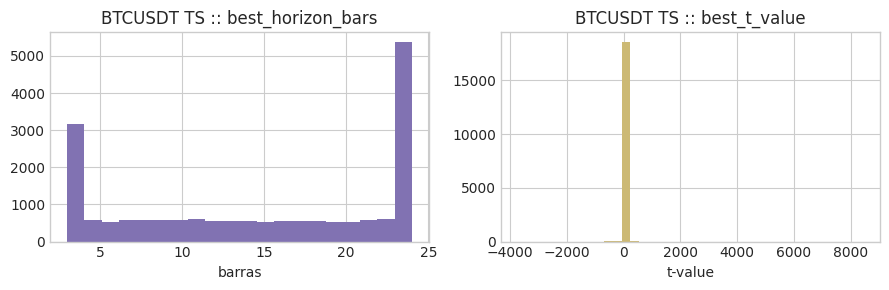

In [12]:
ts_df = event_labels_by_method.get("trend_scanning")
if ts_df is None or ts_df.empty:
    display(pd.DataFrame({"warning": ["trend_scanning vacío o no disponible"]}))
else:
    ts_summary = pd.DataFrame([{
        "eventos": int(len(ts_df)),
        "best_horizon_media": round(float(ts_df["best_horizon_bars"].mean()), 3),
        "best_horizon_p50": int(ts_df["best_horizon_bars"].median()),
        "best_horizon_p95": int(ts_df["best_horizon_bars"].quantile(0.95)),
        "abs_t_value_media": round(float(ts_df["best_t_value"].abs().mean()), 4),
        "abs_t_value_p95": round(float(ts_df["best_t_value"].abs().quantile(0.95)), 4),
        "coherencia_signo_pendiente_vs_label_side": round(
            float((ts_df["best_slope_sign"] == ts_df["label_side"]).mean()), 4
        ),
    }], index=["trend_scanning"]).rename_axis("metodo")
    display(ts_summary)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    axes[0].hist(ts_df["best_horizon_bars"], bins=20, color="#8172B2")
    axes[0].set_title(f"{PILOT_SYMBOL} TS :: best_horizon_bars")
    axes[0].set_xlabel("barras")
    axes[1].hist(ts_df["best_t_value"], bins=40, color="#CCB974")
    axes[1].set_title(f"{PILOT_SYMBOL} TS :: best_t_value")
    axes[1].set_xlabel("t-value")
    fig.tight_layout()
    ts_fig_path = REPORT_DIR / f"trend_scanning_descriptors_{PILOT_SYMBOL.lower()}.png"
    fig.savefig(ts_fig_path, dpi=120)
    plt.show()

## 9. Coherencia entre `event_outcome` y `label_side`

`event_outcome` es el signo crudo de `label_return` (sin banda neutra ni umbral) y se usa como *ground truth* para una eventual fase de *meta-labeling*. `label_side` aplica la lógica de método (banda, vertical, `t-value`).

La proporción de clase neutra en `label_side` ya se reporta en la sección 4; aquí se cuantifica solo el **coste de la neutralización** frente al signo crudo:

- `proporcion_outcome_neutralizado`: eventos con `label_side = 0` pero `event_outcome ≠ 0` (retorno direccional colapsado a neutro),
- `proporcion_desacuerdo_direccional`: eventos con ambos signos direccionales pero distintos (`label_side ≠ event_outcome`, ninguno es `0`).


In [13]:
coherence_rows = []
for method_name, labels_df in event_labels_by_method.items():
    side = labels_df["label_side"].astype(int)
    outcome = labels_df["event_outcome"].astype(int)
    neutralized = (side == NEUTRAL_LABEL_SIDE) & (outcome != 0)
    sign_disagree = (side != NEUTRAL_LABEL_SIDE) & (outcome != 0) & (side != outcome)
    coherence_rows.append(
        {
            "method": method_name,
            "events": int(len(labels_df)),
            "neutralized_nonzero_outcome_share": float(neutralized.mean()),
            "directional_sign_disagreement_share": float(sign_disagree.mean()),
        }
    )
coherence_df = pd.DataFrame(coherence_rows).set_index("method")
coherence_df = coherence_df.rename(columns=COHERENCE_COLUMNS_ES).rename_axis("metodo")
coherence_df.index = coherence_df.index.map(lambda k: CLASS_DIST_METHOD_LABELS.get(k, k))
display(coherence_df)

,eventos,proporcion_outcome_neutralizado,proporcion_desacuerdo_direccional
metodo,,,
fixed_horizon,18701,0.2106,0.0000
"triple_barrier (baseline: all_bars, neutral_vertical)",18701,0.3283,0.0000
"triple_barrier (Exp1: cusum, return_sign_vertical)",6063,0.0000,0.0000
trend_scanning,18683,0.0068,0.0420


## 10. Solape cross-method (matrices de confusión)

Las tres familias etiquetan **el mismo proceso de precios** pero con criterios distintos. Cuantificar el grado de acuerdo en el índice **común** de eventos ayuda a interpretar resultados aguas abajo: si dos métodos discrepan sistemáticamente, no se solapan en la información que ven los modelos y aportan valor por separado al estudio.

Para cada par de triple barrera vs `{trend_scanning, fixed_horizon}` se reportan **dos** variantes de TB:

- `triple_barrier_exp1` (alineada a la lista corta baseline / campaña Exp1),
- `triple_barrier_baseline` (contraste pedagógico: `all_bars` + vertical neutra).

Métricas por par:

- `n_comun`: timestamps `event_start_ts` presentes en ambos,
- `acuerdo_pct`: proporción de igualdad en `label_side`,
- matriz de confusión 3×3 exportada a `reports/eda/target_labeling_methodology/`.

En el piloto (`BTCUSDT`), CUSUM **reduce** el índice común (`n_comun` ~6,000 frente a ~18,700 en la variante *baseline*), pero sobre ese subconjunto el **acuerdo** con *fixed_horizon* y *trend_scanning* es **mayor** (65.7–75.6 % en la corrida registrada) que el observado entre *baseline* y esos métodos (45.7–68.6 %). Eso no indica fallo del labeler, sino muestreo distinto sobre el mismo OHLCV; la variante `baseline` queda como contraste pedagógico.

,n_comun,acuerdo_pct
par,,
"triple_barrier (Exp1: cusum, return_sign_vertical) vs. trend_scanning",6058,0.6570
"triple_barrier (Exp1: cusum, return_sign_vertical) vs. fixed_horizon",6063,0.7561
"triple_barrier (baseline: all_bars, neutral_vertical) vs. trend_scanning",18683,0.4574
"triple_barrier (baseline: all_bars, neutral_vertical) vs. fixed_horizon",18701,0.6856


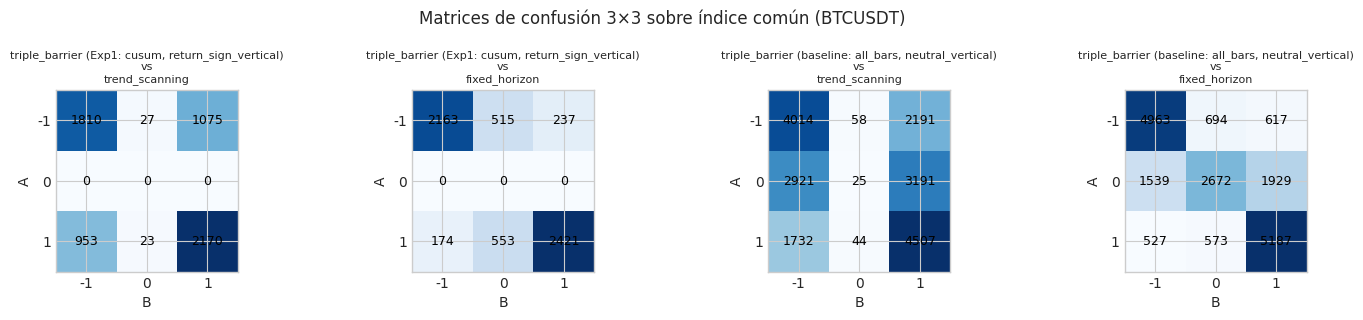

In [14]:
def _confusion_3x3(a: pd.Series, b: pd.Series) -> pd.DataFrame:
    cats = [-1, 0, 1]
    cm = pd.crosstab(a, b, rownames=["A"], colnames=["B"])
    return cm.reindex(index=cats, columns=cats, fill_value=0)


def _cross_compare(method_a: str, method_b: str) -> dict:
    a = event_labels_by_method[method_a].set_index("event_start_ts")["label_side"].astype(int)
    b = event_labels_by_method[method_b].set_index("event_start_ts")["label_side"].astype(int)
    common = a.index.intersection(b.index)
    a_c, b_c = a.loc[common], b.loc[common]
    cm = _confusion_3x3(a_c, b_c)
    n = int(len(common))
    agree = float((a_c == b_c).mean()) if n else 0.0
    return {"method_a": method_a, "method_b": method_b, "n_common": n,
            "agreement_pct": round(agree, 4), "confusion_matrix": cm}


cross_pairs = [
    ("triple_barrier_exp1", "trend_scanning"),
    ("triple_barrier_exp1", "fixed_horizon"),
    ("triple_barrier_baseline", "trend_scanning"),
    ("triple_barrier_baseline", "fixed_horizon"),
]
cross_results = [_cross_compare(a, b) for a, b in cross_pairs]
cross_summary_df = pd.DataFrame(
    [{
        "par": f"{CLASS_DIST_METHOD_LABELS.get(r['method_a'], r['method_a'])} vs. "
               f"{CLASS_DIST_METHOD_LABELS.get(r['method_b'], r['method_b'])}",
        "n_comun": r["n_common"],
        "acuerdo_pct": r["agreement_pct"],
    } for r in cross_results]
).set_index("par")
display(cross_summary_df)

n_pairs = len(cross_results)
fig, axes = plt.subplots(1, n_pairs, figsize=(3.6 * n_pairs, 3.2))
if n_pairs == 1:
    axes = [axes]
for ax, res in zip(axes, cross_results):
    cm = res["confusion_matrix"]
    im = ax.imshow(cm.values, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_xticklabels(cm.columns)
    ax.set_yticks(range(3)); ax.set_yticklabels(cm.index)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, int(cm.values[i, j]), ha="center", va="center", color="black", fontsize=9)
    title_a = CLASS_DIST_METHOD_LABELS.get(res["method_a"], res["method_a"])
    title_b = CLASS_DIST_METHOD_LABELS.get(res["method_b"], res["method_b"])
    ax.set_title(f"{title_a}\nvs\n{title_b}", fontsize=8)
    ax.set_xlabel("B")
    ax.set_ylabel("A")
fig.suptitle(f"Matrices de confusión 3×3 sobre índice común ({PILOT_SYMBOL})")
fig.tight_layout()
cross_fig_path = REPORT_DIR / f"cross_method_confusion_{PILOT_SYMBOL.lower()}.png"
fig.savefig(cross_fig_path, dpi=120)
plt.show()

## 11. Cierre metodológico

- La definición formal de cada método y su semántica operativa está congelada en el contrato del laboratorio de *targets*; este notebook **no** la redefine, solo la audita.
- Las secciones 4 y 5 cubren **utilizabilidad estadística** (balance de clases, solapamiento y purga/embargo); las secciones 6, 7 y 8 cubren **solidez operativa** (integridad, causalidad, coherencia física de TB y coherencia interna de TS).
- La sección 9 cuantifica el coste de la banda neutra frente al signo crudo del retorno; la sección 10 el solape entre familias. CUSUM concentra el índice común en ~6,000 eventos, pero sobre ellos el acuerdo con métodos *bar-by-bar* supera al de la variante *baseline* pedagógica; la variante `baseline` no es la que se materializa en producción.
- La **decisión de materialización** (tres métodos del contrato + variante TB de `baseline_shortlist.yaml`) se cierra en la memoria del TFG (cap. 2), apoyándose en las tablas y figuras de este notebook.
- La elección del método **campeón** se cierra aguas abajo en `05_modelado_predictivo/01_evidencia_shortlist_baseline.ipynb` a partir de *bundles* persistidos.
- Persistencia productiva: FH/TS en `data/03_processed/targets/<SYMBOL>/<METHOD>/`; TB Exp1 en `data/03_processed/exp1_triple_barrier_cusum_return_sign/targets/<SYMBOL>/triple_barrier/`. El *modeling dataset* se materializa desde `03_dataset_supervisado/01_evidencia_dataset_modelado.ipynb`; este notebook no persiste parquets.
